# Replicated Results

In this notebook we illustrate how the main functions in the package pig_vi hosted on GitHub (at https://github.com/jguntrip42/pig_review_repo.git) may be used to replicate the results stated in our paper.

## Replication of Figure 2: Piglet convergence

First we import the relevant module.

In [1]:
from pig_vi.piglet_vi import *

Then we define the states, actions, probabillity function and reward function for the piglet value iteration algorithm.

In [2]:
piglet_states = [(0,0,0),(0,0,1),(0,1,0),(0,1,1),(1,0,0),(1,1,0),(1,0,1),(1,1,1),(0,0,2),(0,1,2),"WIN"]
piglet_actions = ["H","F"]

target = 2


def P_piglet(s_new,s,a):
    """Returns probabilities for taking action a in state s and transitioning to state s_new"""
    
    if s != "WIN":
        if a == "F":
            if (s[0] == s_new[0] and s[1] == s_new[1] and s_new[2] == 0): # Case where we obtain tails
                p = 0.5
            elif (s[0] == s_new[0] and s[1] == s_new[1] and (s[2]+1) == s_new[2]): # Case where we obtain heads
                p = 0.5
            else:
                p = 0
        elif a == "H":
            if ((s[0]+s[2]) == s_new[0]) and (s[1] == s_new[1]) and (s_new[2] == 0) and ((s[2]+s[0]) != target): # Case where one holds but doesn't win immediately
                p = 1
            elif ((s[2]+s[0]) == target) and (s_new == "WIN"): # Case where holding will inveitably cause the player to win
                p = 1
            else:
                p = 0
    else:
        p = 0
        
    return p


def R_piglet(s_new,s,a):
    """Returns the reward for performing action a and moving from state s to state s_new"""
    
    if ((s_new == "WIN") and (a == "H") and ((s[2]+s[0]) == target)): # Reward only when player wins
        r = 1
    else:
        r = 0
    
    return r

We call the piglet_val_iteration function to obtain the results.

In [6]:
new_policy,val_map_0,val_dict_0 = piglet_val_iteration(piglet_states,piglet_actions,P_piglet,R_piglet,target,0.00001)
val_map_0

{(0, 0, 0): 0.5714285969734192,
 (0, 0, 1): 0.7142857313156128,
 (0, 1, 0): 0.4000133275985718,
 (0, 1, 1): 0.6000075936317444,
 (1, 0, 0): 0.7999899387359619,
 (1, 1, 0): 0.6666666865348816,
 (1, 0, 1): 1.0,
 (1, 1, 1): 1.0,
 (0, 0, 2): 1.0,
 (0, 1, 2): 1.0,
 'WIN': 0}

We can then plot the results.

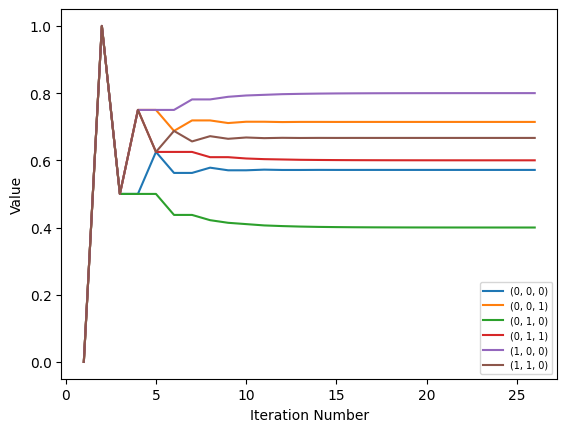

In [4]:
import matplotlib.pyplot as plt

iteration_nums = [i for i in range(1,27,1)]


fig, ax_1 = plt.subplots()

for i in range(0,6):
    ax_1.plot(iteration_nums,val_dict_0[piglet_states[i]],label=str(piglet_states[i]))

plt.xlabel("Iteration Number")
plt.ylabel("Value")
plt.legend(loc="lower right",fontsize="x-small")
plt.show()

## Replication of Figure 3: optimal policy boundary

## Replication of Figure 4: cross-section for opponent score fixed at 30

## Replication of Figure 5: reachable states

## Replication of Figure 6: reachable states when rolling is optimal

## Replication of Figure 7: win-probability contours

## Key metrics